### ***`🌍 Air Quality Index (AQI) Prediction using Machine Learning`***

---



Objective: Predict Air Quality Index based on environmental factors using various ML algorithms

---
# 1. Importing Libraries

---



In [1]:
# For Data Handling
import pandas as pd
import numpy as np

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Algorithm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

#Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#Datetime
from datetime import datetime

---
# 2. Loading Dataset

---



In [2]:
# Importing Dataset from Drive

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/city_day.csv')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# 3. Dataset Preview

---



In [3]:
df.shape

(29531, 16)

In [4]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [5]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [6]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [8]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [9]:
df.duplicated().sum()

np.int64(0)

---
# 4. Data Cleaning  
---
Handling Missing Values


---



In [10]:
# Only important columns

columns_to_keep = ['City', 'Date','PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']
df_clean = df[columns_to_keep].copy()

In [11]:
# Dropping ALL rows with ANY missing values
df_clean = df_clean.dropna()

# Reset index after dropping
df_clean = df_clean.reset_index(drop=True)

df_clean.shape

(16010, 9)

In [12]:
# Converting Date to datetime and extracting features
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day



In [13]:
# Drop original Date column (we extracted what we need)
df_clean = df_clean.drop('Date', axis=1)

df_clean.head()

,City,PM2.5,PM10,NO2,CO,SO2,O3,AQI,Year,Month,Day
0,Ahmedabad,37.55,122.41,85.12,15.08,163.01,48.23,281.0,2019,5,15
1,Ahmedabad,33.97,116.32,79.71,14.67,91.26,51.86,330.0,2019,5,16
2,Ahmedabad,35.48,130.07,77.61,18.02,98.35,38.99,356.0,2019,5,17
3,Ahmedabad,34.11,138.31,75.23,13.27,88.66,42.22,359.0,2019,5,18
4,Ahmedabad,33.69,111.73,68.90,34.56,80.90,36.95,547.0,2019,5,19


---
# 4.1 One - Hot Encoding

---

for City Column


---




In [14]:
# One-Hot Encoding for City column
df_clean = pd.get_dummies(df_clean, columns=['City'], drop_first=True)

df_clean.shape

(16010, 33)

In [15]:
# Final Check
df_clean.head()

,PM2.5,PM10,NO2,CO,SO2,O3,AQI,Year,Month,Day,...,City_Jaipur,City_Jorapokhar,City_Kochi,City_Kolkata,City_Mumbai,City_Patna,City_Shillong,City_Talcher,City_Thiruvananthapuram,City_Visakhapatnam
0,37.55,122.41,85.12,15.08,163.01,48.23,281.0,2019,5,15,...,False,False,False,False,False,False,False,False,False,False
1,33.97,116.32,79.71,14.67,91.26,51.86,330.0,2019,5,16,...,False,False,False,False,False,False,False,False,False,False
2,35.48,130.07,77.61,18.02,98.35,38.99,356.0,2019,5,17,...,False,False,False,False,False,False,False,False,False,False
3,34.11,138.31,75.23,13.27,88.66,42.22,359.0,2019,5,18,...,False,False,False,False,False,False,False,False,False,False
4,33.69,111.73,68.90,34.56,80.90,36.95,547.0,2019,5,19,...,False,False,False,False,False,False,False,False,False,False


---
# 5. Exploratory Data Analysis (EDA)

---

Understanding patterns and relationships in our clean data.


---



In [16]:
# Statistical Summary of clean data

df_clean.describe()

,PM2.5,PM10,NO2,CO,SO2,O3,AQI,Year,Month,Day
count,16010.000000,16010.000000,16010.000000,16010.000000,16010.000000,16010.000000,16010.000000,16010.000000,16010.000000,16010.000000
mean,57.342885,117.697931,29.112615,1.434911,12.785969,35.132273,141.355715,2018.473142,6.215928,15.796252
std,52.096518,88.484088,22.830288,3.548884,13.496148,21.525602,104.325680,1.305316,3.503142,8.826481
min,0.160000,0.180000,0.010000,0.000000,0.010000,0.010000,14.000000,2015.000000,1.000000,1.000000
25%,25.040000,56.620000,12.450000,0.560000,6.120000,19.680000,74.000000,2018.000000,3.000000,8.000000
50%,42.910000,95.625000,24.105000,0.840000,9.710000,31.965000,107.000000,2019.000000,6.000000,16.000000
75%,69.800000,148.697500,39.370000,1.247500,14.677500,46.200000,167.000000,2019.000000,9.000000,23.000000
max,868.660000,847.410000,277.310000,92.960000,186.080000,257.730000,1389.000000,2020.000000,12.000000,31.000000


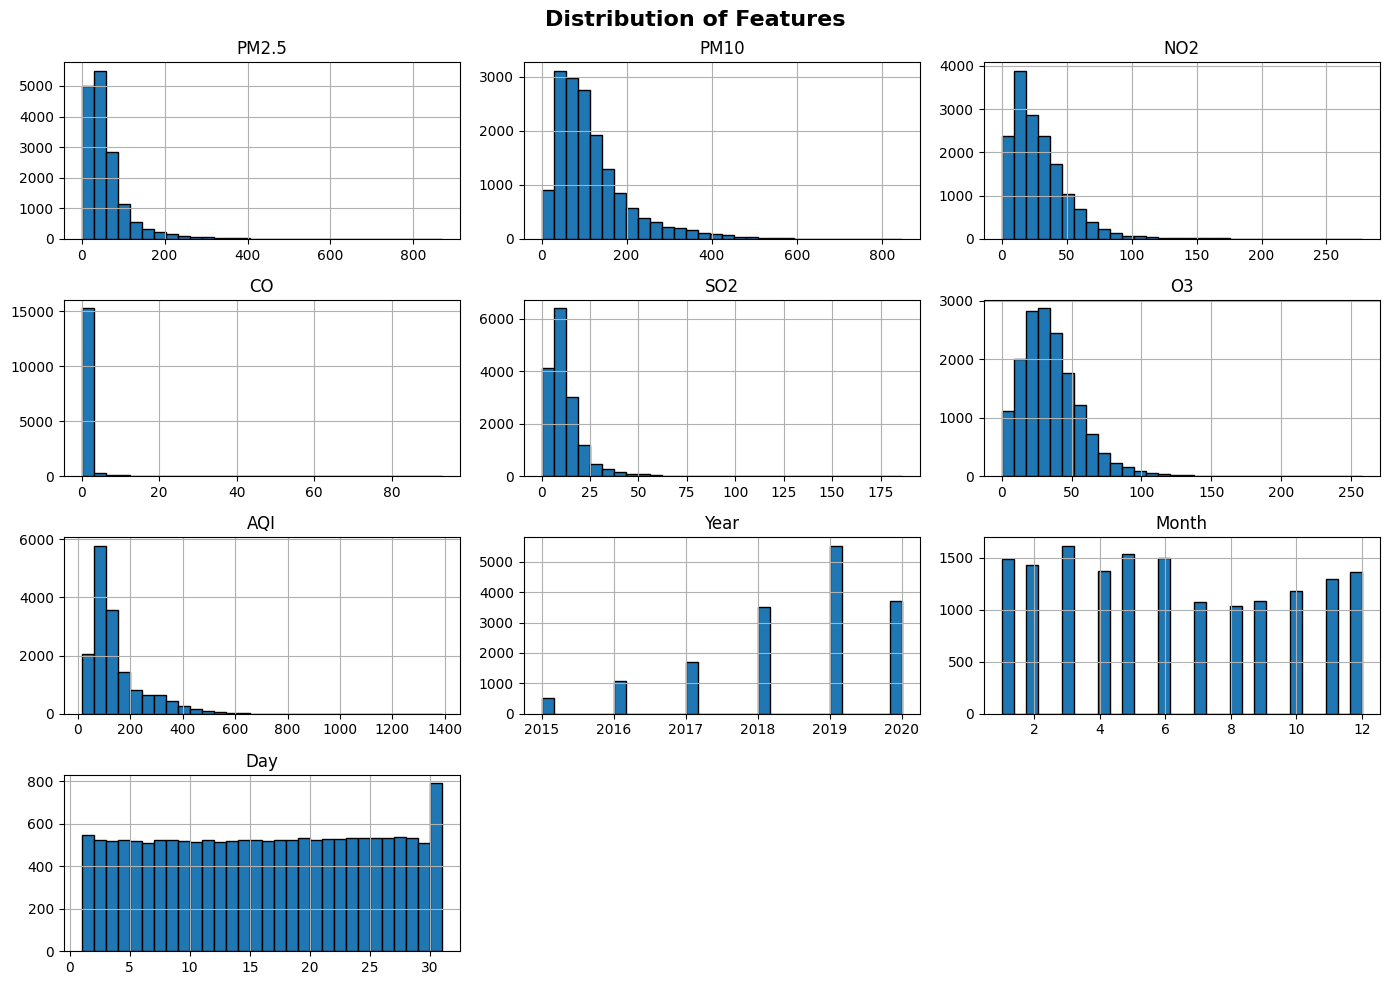

In [17]:
# Distribution of all features

df_clean.hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Correlation of numerical features with AQI

numerical_cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'Year', 'Month', 'Day', 'AQI']
df_clean[numerical_cols].corr()['AQI'].sort_values(ascending=False)

,AQI
AQI,1.000000
PM10,0.807309
PM2.5,0.789445
NO2,0.611989
CO,0.546648
SO2,0.461186
O3,0.297086
Month,0.013798
Day,-0.018230
Year,-0.220212


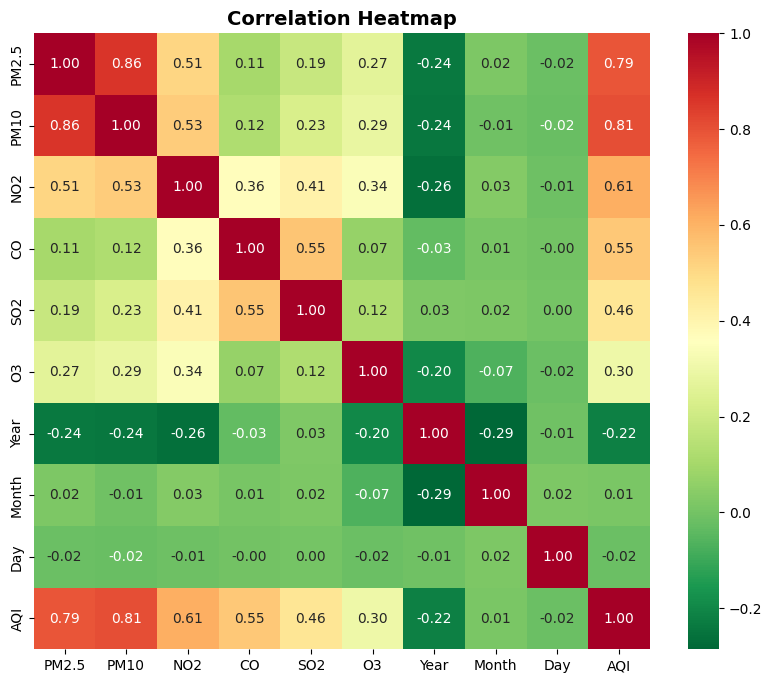

In [19]:
# Correlation heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[numerical_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn_r', square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

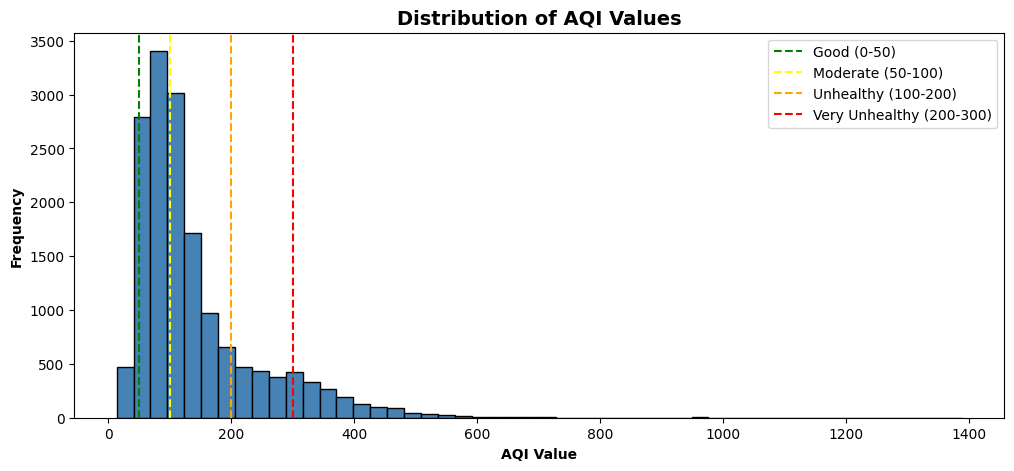

In [20]:
# AQI distribution with category colors

plt.figure(figsize=(12, 5))
plt.hist(df_clean['AQI'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(50, color='green', linestyle='--', label='Good (0-50)')
plt.axvline(100, color='yellow', linestyle='--', label='Moderate (50-100)')
plt.axvline(200, color='orange', linestyle='--', label='Unhealthy (100-200)')
plt.axvline(300, color='red', linestyle='--', label='Very Unhealthy (200-300)')
plt.xlabel('AQI Value', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of AQI Values', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

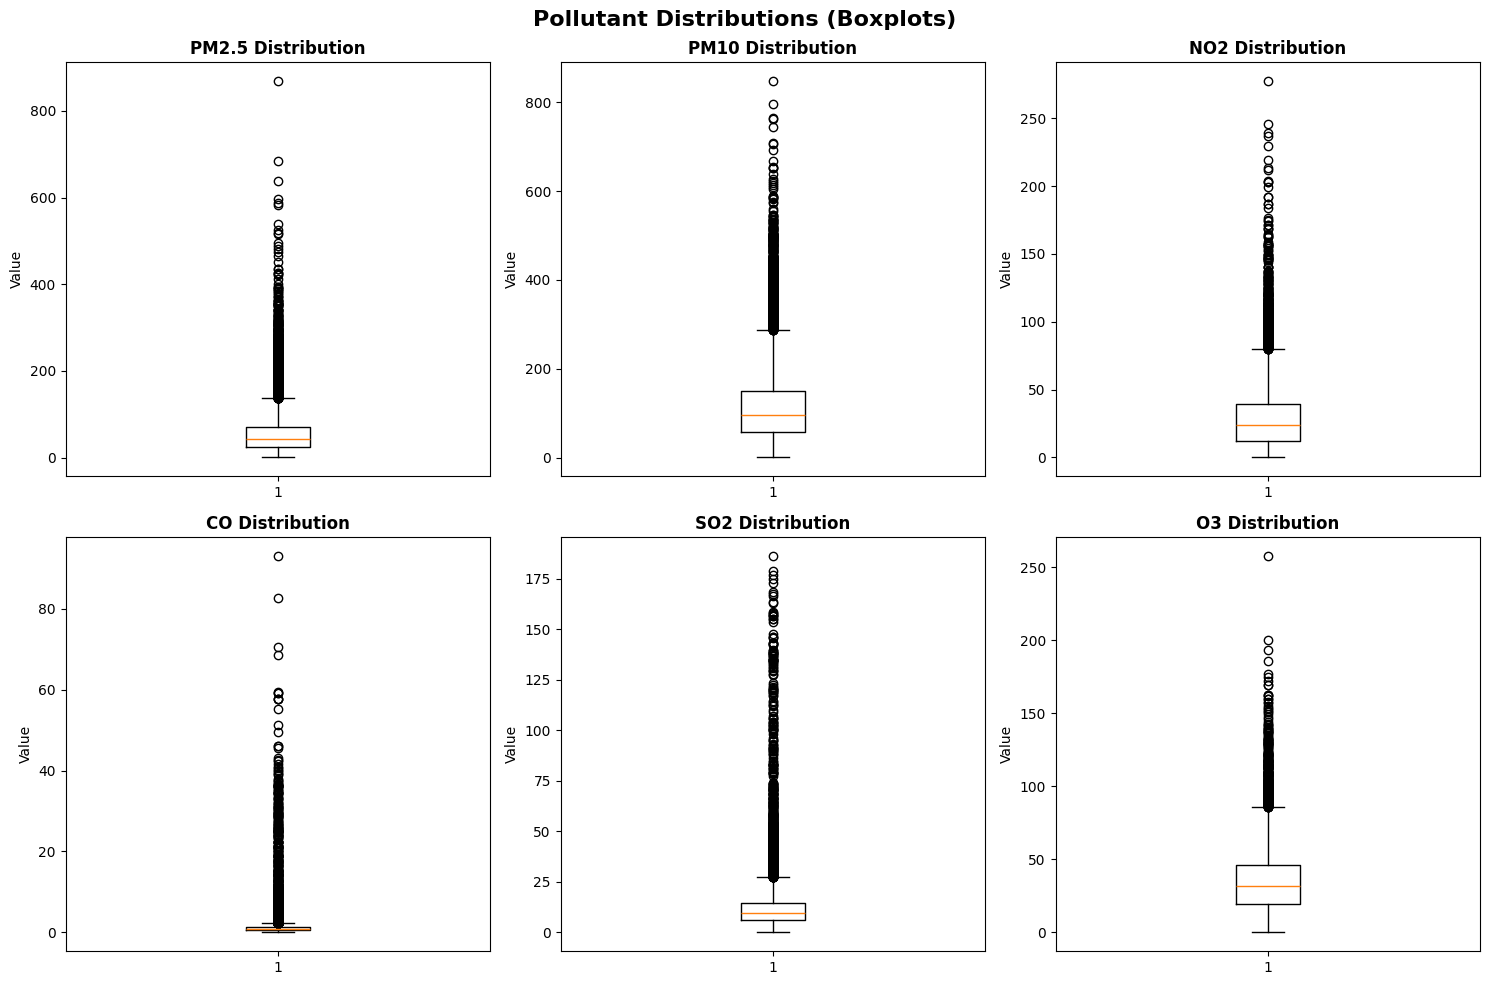

In [21]:
# Boxplots for all pollutants

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

for i, col in enumerate(pollutants):
    row = i // 3
    col_idx = i % 3
    axes[row, col_idx].boxplot(df_clean[col])
    axes[row, col_idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[row, col_idx].set_ylabel('Value')

plt.suptitle('Pollutant Distributions (Boxplots)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

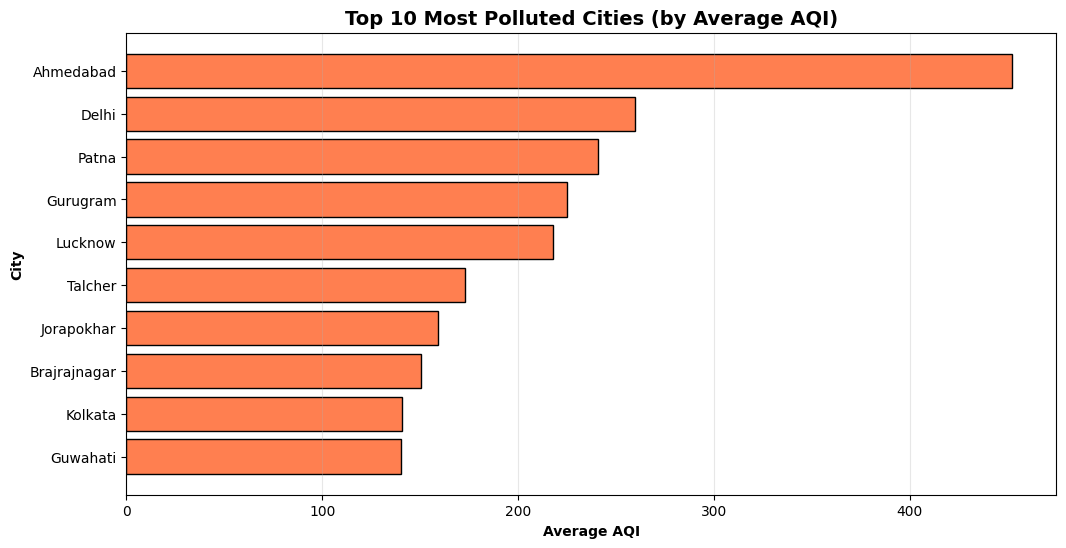

In [22]:
# Top 10 cities by average AQI (using original df before encoding)
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(city_aqi.index, city_aqi.values, color='coral', edgecolor='black')
plt.xlabel('Average AQI', fontweight='bold')
plt.ylabel('City', fontweight='bold')
plt.title('Top 10 Most Polluted Cities (by Average AQI)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

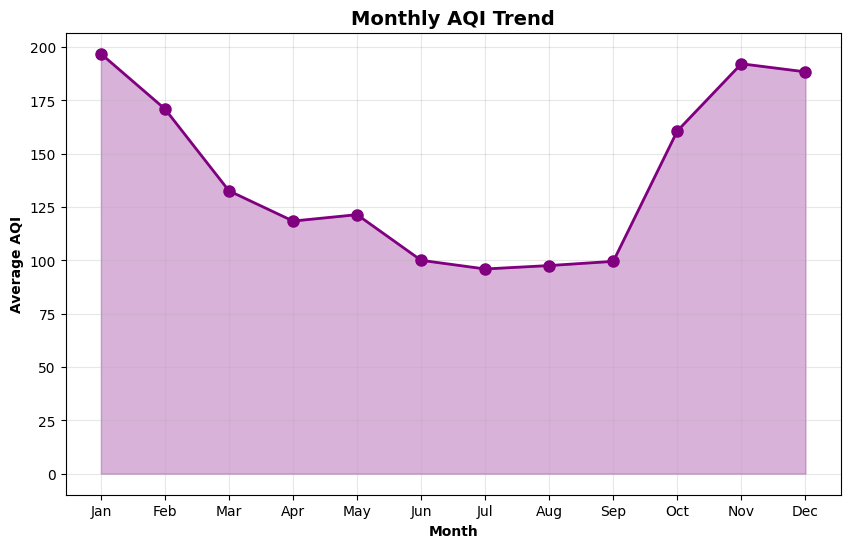

In [23]:
# Monthly AQI trend
monthly_aqi = df_clean.groupby('Month')['AQI'].mean()

plt.figure(figsize=(10, 6))
plt.plot(monthly_aqi.index, monthly_aqi.values, marker='o', linewidth=2, markersize=8, color='purple')
plt.fill_between(monthly_aqi.index, monthly_aqi.values, alpha=0.3, color='purple')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Average AQI', fontweight='bold')
plt.title('Monthly AQI Trend', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(alpha=0.3)
plt.show()

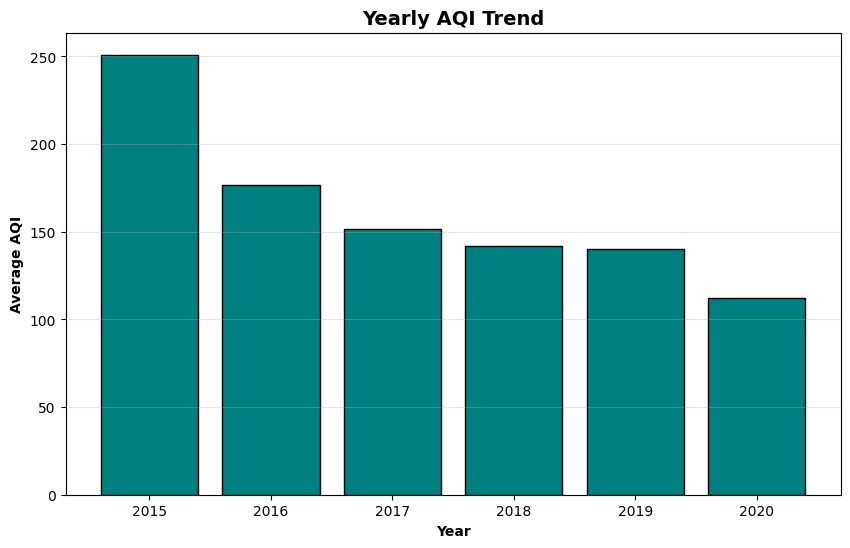

In [24]:
# Yearly AQI trend
yearly_aqi = df_clean.groupby('Year')['AQI'].mean()

plt.figure(figsize=(10, 6))
plt.bar(yearly_aqi.index, yearly_aqi.values, color='teal', edgecolor='black')
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Average AQI', fontweight='bold')
plt.title('Yearly AQI Trend', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

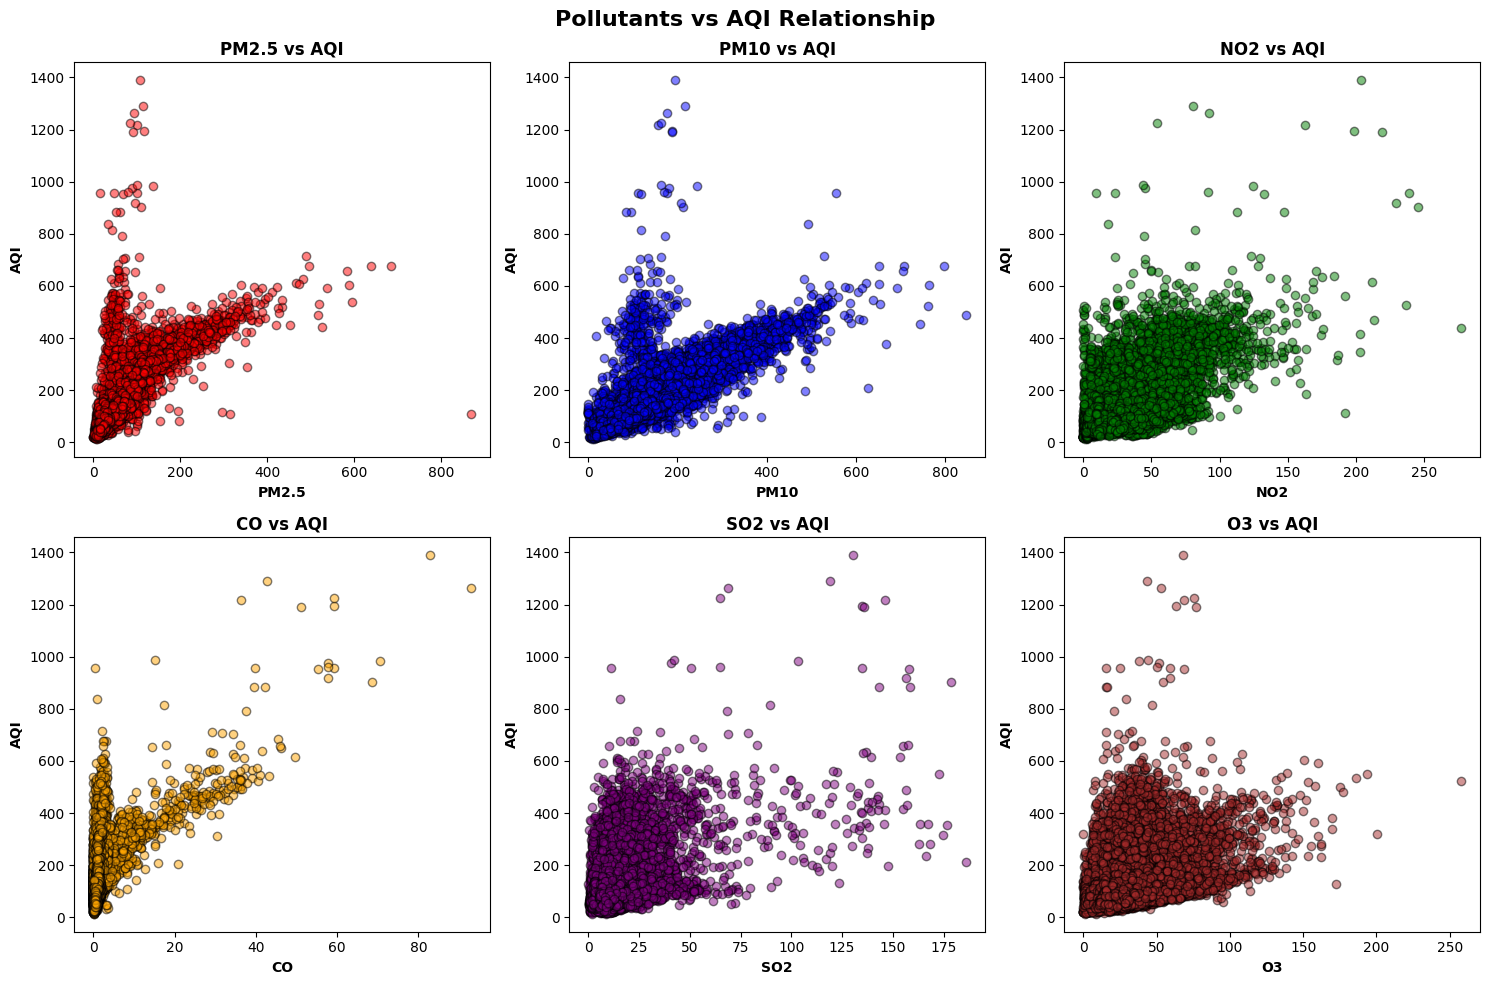

In [25]:
# Scatter plots: Pollutants vs AQI
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

for i, col in enumerate(pollutants):
    row = i // 3
    col_idx = i % 3
    axes[row, col_idx].scatter(df_clean[col], df_clean['AQI'], alpha=0.5, color=colors[i], edgecolor='black')
    axes[row, col_idx].set_xlabel(col, fontweight='bold')
    axes[row, col_idx].set_ylabel('AQI', fontweight='bold')
    axes[row, col_idx].set_title(f'{col} vs AQI', fontweight='bold')

plt.suptitle('Pollutants vs AQI Relationship', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 6. Preparing Data for Model

---




In [26]:
# Splitting features (X) and target (y)
X = df_clean.drop('AQI', axis=1)
y = df_clean['AQI']

X.shape, y.shape

((16010, 32), (16010,))

In [27]:
# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((12808, 32), (3202, 32))

In [28]:
# Scaling features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(12808, 32)

---
# 7. Building Machine Learning Models

---


*  Linear Regression
*  Decision Tree Regressor
*  Randon Forest Regressor
*  Support Vector Regressor
*  K- Nearest Neighbors Regressor


---



In [29]:
# Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("Linear Regression R² Score:", r2_score(y_test, lr_pred))

Linear Regression R² Score: 0.9057812045272104


In [30]:
# Decision Tree Regressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)

print("Decision Tree R² Score:", r2_score(y_test, dt_pred))

Decision Tree R² Score: 0.869728843816047


In [31]:
# Random Forest Regressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest R² Score:", r2_score(y_test, rf_pred))

Random Forest R² Score: 0.9290957643398193


In [32]:
# Support Vector Regressor

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)
svr_pred = svr_model.predict(X_test_scaled)

print("SVR R² Score:", r2_score(y_test, svr_pred))

SVR R² Score: 0.7086202545899023


In [33]:
# K-Nearest Neighbors Regressor

knn_model = KNeighborsRegressor()
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

print("KNN R² Score:", r2_score(y_test, knn_pred))

KNN R² Score: 0.9168183640005103


---
# 8. Model Comparison and Visualization

---



In [34]:
# Creating comparison dataframe

models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'KNN']
r2_scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred),
    r2_score(y_test, svr_pred),
    r2_score(y_test, knn_pred)
]

comparison_df = pd.DataFrame({'Model': models, 'R² Score': r2_scores})
comparison_df = comparison_df.sort_values('R² Score', ascending=False)
comparison_df

,Model,R² Score
2,Random Forest,0.929096
4,KNN,0.916818
0,Linear Regression,0.905781
1,Decision Tree,0.869729
3,SVR,0.708620


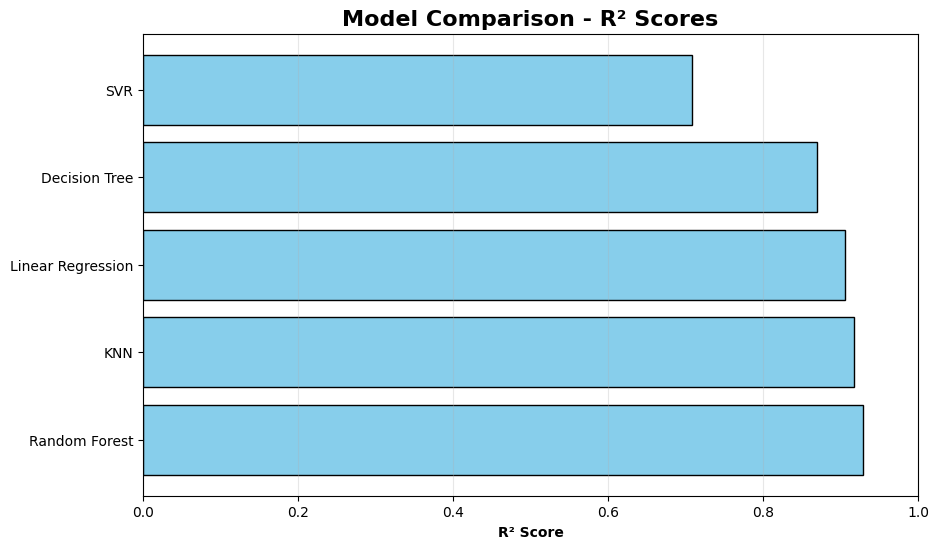

In [35]:
# Bar chart comparison

plt.figure(figsize=(10, 6))
plt.barh(comparison_df['Model'], comparison_df['R² Score'], color='skyblue', edgecolor='black')
plt.xlabel('R² Score', fontweight='bold')
plt.title('Model Comparison - R² Scores', fontsize=16, fontweight='bold')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.show()

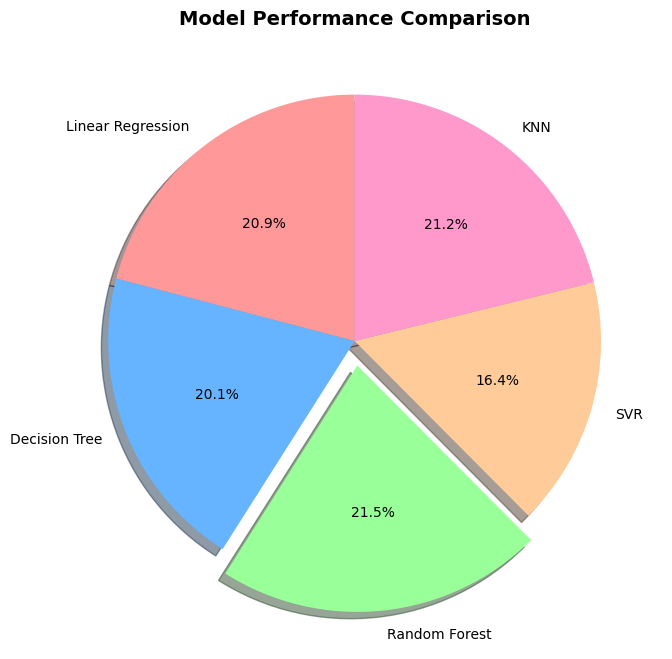

In [36]:
# Pie chart showing relative performance
plt.figure(figsize=(8, 8))
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'KNN']
scores = [r2_score(y_test, lr_pred), r2_score(y_test, dt_pred),
          r2_score(y_test, rf_pred), r2_score(y_test, svr_pred),
          r2_score(y_test, knn_pred)]
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
explode = (0, 0, 0.1, 0, 0)

plt.pie(scores, explode=explode, labels=models, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.show()

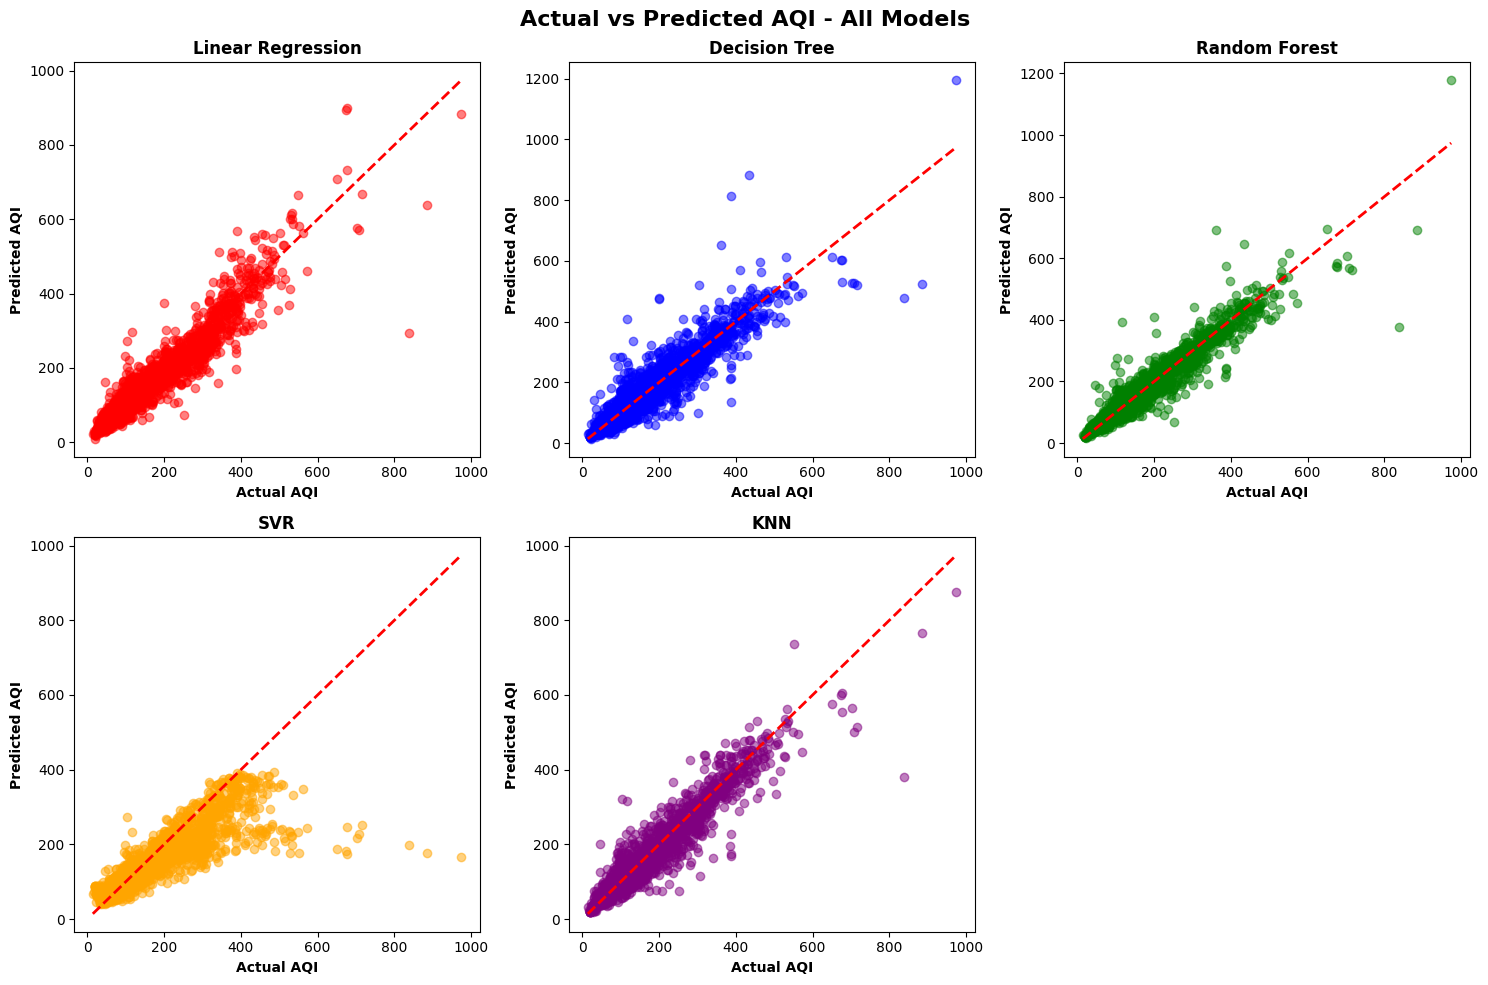

In [37]:
# Actual vs Predicted comparison for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

predictions = [lr_pred, dt_pred, rf_pred, svr_pred, knn_pred]
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'KNN']
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, (pred, model) in enumerate(zip(predictions, models)):
    row = i // 3
    col_idx = i % 3
    axes[row, col_idx].scatter(y_test, pred, alpha=0.5, color=colors[i])
    axes[row, col_idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[row, col_idx].set_xlabel('Actual AQI', fontweight='bold')
    axes[row, col_idx].set_ylabel('Predicted AQI', fontweight='bold')
    axes[row, col_idx].set_title(f'{model}', fontweight='bold')

# Remove empty subplot
fig.delaxes(axes[1, 2])

plt.suptitle('Actual vs Predicted AQI - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

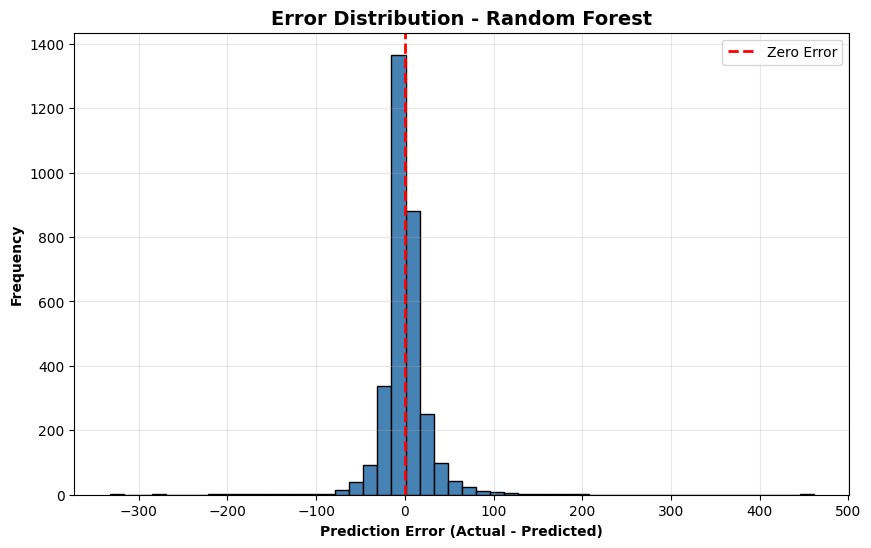

In [38]:
# Error distribution for best model (Random Forest)
errors = y_test - rf_pred

plt.figure(figsize=(10, 6))
plt.hist(errors, bins=50, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Error Distribution - Random Forest', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [39]:
# Feature Importance (Random Forest)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
0,PM2.5,0.584394
3,CO,0.240321
1,PM10,0.124968
5,O3,0.011560
2,NO2,0.008314
4,SO2,0.006981
18,City_Delhi,0.005591
6,Year,0.004591
8,Day,0.004218
7,Month,0.002807


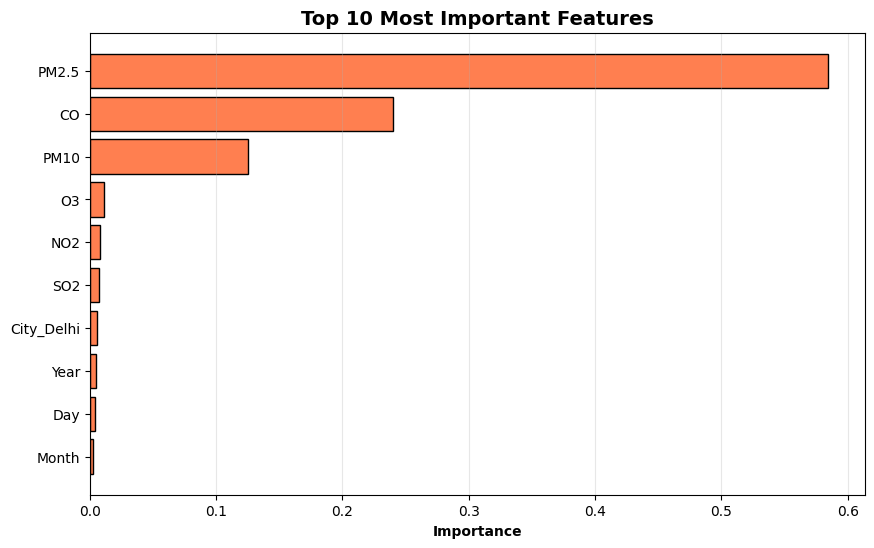

In [40]:
# Feature Importance Bar Chart

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Feature'], top_features['Importance'], color='coral', edgecolor='black')
plt.xlabel('Importance', fontweight='bold')
plt.title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

---
# 8.1 Evaluation Metrics


---
*   R² Score - How well model explains variance | Closer to 1 |
*   MAE - Average prediction error | Lower is better |
*   RMSE - Penalizes large errors more | Lower is better |


---



In [41]:
# Evaluation metrics for all models
results = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'KNN'],
    'R² Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, svr_pred),
        r2_score(y_test, knn_pred)
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, svr_pred),
        mean_absolute_error(y_test, knn_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, svr_pred)),
        np.sqrt(mean_squared_error(y_test, knn_pred))
    ]
}

eval_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)
eval_df

,Model,R² Score,MAE,RMSE
2,Random Forest,0.929096,15.465390,27.780706
4,KNN,0.916818,17.678139,30.089912
0,Linear Regression,0.905781,20.367806,32.024029
1,Decision Tree,0.869729,21.832605,37.655752
3,SVR,0.708620,27.616448,56.316657


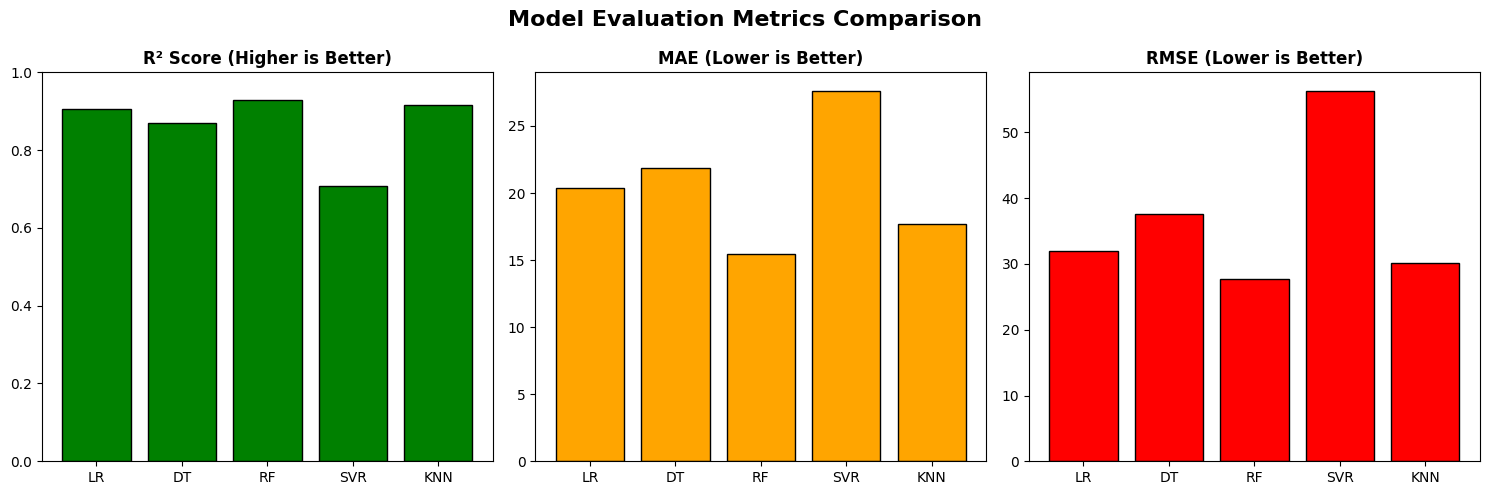

In [42]:
# Metrics comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = ['LR', 'DT', 'RF', 'SVR', 'KNN']

# R² Score
r2_scores = [r2_score(y_test, lr_pred), r2_score(y_test, dt_pred),
             r2_score(y_test, rf_pred), r2_score(y_test, svr_pred),
             r2_score(y_test, knn_pred)]
axes[0].bar(models, r2_scores, color='green', edgecolor='black')
axes[0].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[0].set_ylim(0, 1)

# MAE
mae_scores = [mean_absolute_error(y_test, lr_pred), mean_absolute_error(y_test, dt_pred),
              mean_absolute_error(y_test, rf_pred), mean_absolute_error(y_test, svr_pred),
              mean_absolute_error(y_test, knn_pred)]
axes[1].bar(models, mae_scores, color='orange', edgecolor='black')
axes[1].set_title('MAE (Lower is Better)', fontweight='bold')

# RMSE
rmse_scores = [np.sqrt(mean_squared_error(y_test, lr_pred)), np.sqrt(mean_squared_error(y_test, dt_pred)),
               np.sqrt(mean_squared_error(y_test, rf_pred)), np.sqrt(mean_squared_error(y_test, svr_pred)),
               np.sqrt(mean_squared_error(y_test, knn_pred))]
axes[2].bar(models, rmse_scores, color='red', edgecolor='black')
axes[2].set_title('RMSE (Lower is Better)', fontweight='bold')

plt.suptitle('Model Evaluation Metrics Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
# Final Model Evaluation Metrics (Random Forest - Best Model)

from sklearn.metrics import mean_absolute_error, mean_squared_error

print("="*60)
print("BEST MODEL: RANDOM FOREST REGRESSOR")
print("="*60)
print(f"R² Score:  {r2_score(y_test, rf_pred):.4f}")
print(f"MAE:       {mean_absolute_error(y_test, rf_pred):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}")
print("="*60)


BEST MODEL: RANDOM FOREST REGRESSOR
R² Score:  0.9291
MAE:       15.4654
RMSE:      27.7807


In [44]:
# Sample Predictions

sample_results = pd.DataFrame({
    'Actual AQI': y_test.values[:10],
    'Predicted AQI': rf_pred[:10],
    'Difference': abs(y_test.values[:10] - rf_pred[:10])
})

sample_results

,Actual AQI,Predicted AQI,Difference
0,86.0,81.81,4.19
1,95.0,77.97,17.03
2,532.0,527.91,4.09
3,386.0,574.24,188.24
4,69.0,63.21,5.79
5,147.0,157.41,10.41
6,103.0,95.11,7.89
7,168.0,146.86,21.14
8,347.0,325.91,21.09
9,48.0,53.30,5.30


---
# 9. Fixing Outliers

---



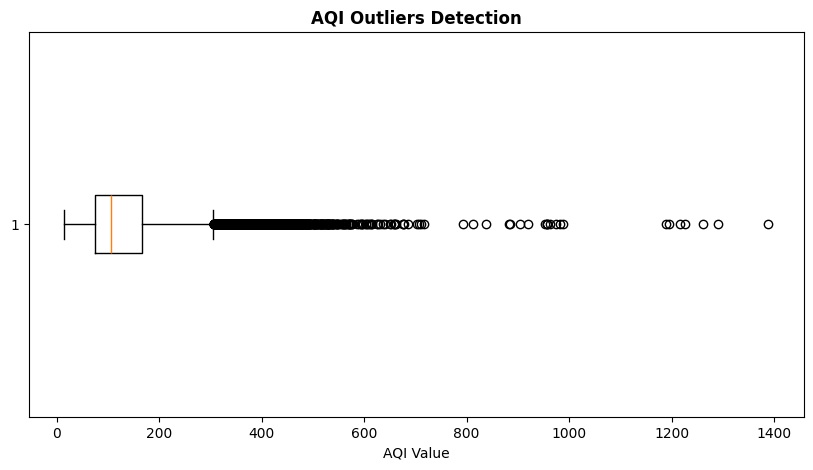

In [45]:
# Check for outliers in AQI

plt.figure(figsize=(10, 5))
plt.boxplot(df_clean['AQI'], vert=False)
plt.xlabel('AQI Value')
plt.title('AQI Outliers Detection', fontweight='bold')
plt.show()

---
# 9.1 Retain Model without Outliers

---



In [46]:
# Remove extreme outliers (AQI > 500 is rare/extreme)

df_clean_no_outliers = df_clean[df_clean['AQI'] <= 500].copy()

print(f"Before: {df_clean.shape[0]} rows")
print(f"After:  {df_clean_no_outliers.shape[0]} rows")
print(f"Removed: {df_clean.shape[0] - df_clean_no_outliers.shape[0]} outliers")

Before: 16010 rows
After:  15873 rows
Removed: 137 outliers


In [47]:
# Split features and target again
X = df_clean.drop('AQI', axis=1)
y = df_clean['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((12808, 32), (3202, 32))

In [48]:
# Scale features again
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(12808, 32)

In [49]:
# Retrain all models
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)
svr_pred = svr_model.predict(X_test_scaled)

knn_model = KNeighborsRegressor()
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)


In [50]:
# New R² Scores
print("NEW R² SCORES (After Removing Outliers)")
print("="*50)
print(f"Linear Regression: {r2_score(y_test, lr_pred):.4f}")
print(f"Decision Tree:     {r2_score(y_test, dt_pred):.4f}")
print(f"Random Forest:     {r2_score(y_test, rf_pred):.4f}")
print(f"SVR:               {r2_score(y_test, svr_pred):.4f}")
print(f"KNN:               {r2_score(y_test, knn_pred):.4f}")
print("="*50)

NEW R² SCORES (After Removing Outliers)
Linear Regression: 0.9058
Decision Tree:     0.8697
Random Forest:     0.9291
SVR:               0.7086
KNN:               0.9168


In [51]:
# Check sample predictions now
sample_results = pd.DataFrame({
    'Actual AQI': y_test.values[:10],
    'Predicted AQI': rf_pred[:10].round(2),
    'Difference': abs(y_test.values[:10] - rf_pred[:10]).round(2)
})

sample_results

,Actual AQI,Predicted AQI,Difference
0,86.0,81.81,4.19
1,95.0,77.97,17.03
2,532.0,527.91,4.09
3,386.0,574.24,188.24
4,69.0,63.21,5.79
5,147.0,157.41,10.41
6,103.0,95.11,7.89
7,168.0,146.86,21.14
8,347.0,325.91,21.09
9,48.0,53.30,5.30


---
# 10. Model Deployment and Prediction


---




In [52]:
# Save the best model (Random Forest)

import pickle

pickle.dump(rf_model, open('aqi_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))



In [53]:
# Create prediction function

def predict_aqi(pm25, pm10, no2, co, so2, o3, city_encoded, year, month, day):
    """
    Predict AQI based on input features
    """
    # Create input array (must match training feature order)
    input_data = [[pm25, pm10, no2, co, so2, o3] + city_encoded + [year, month, day]]

    # Scale the input
    input_scaled = scaler.transform(input_data)

    # Predict
    prediction = rf_model.predict(input_scaled)

    return round(prediction[0], 2)



In [54]:
# Example: Make a prediction
# Sample input values

sample_input = X_test.iloc[0].values.reshape(1, -1)
sample_scaled = scaler.transform(sample_input)
predicted_aqi = rf_model.predict(sample_scaled)[0]
actual_aqi = y_test.iloc[0]

print("="*60)
print("SAMPLE PREDICTION")
print("="*60)
print(f"Input Features: {X_test.iloc[0].to_dict()}")
print(f"\nPredicted AQI: {predicted_aqi:.2f}")
print(f"Actual AQI:    {actual_aqi:.2f}")
print(f"Difference:    {abs(predicted_aqi - actual_aqi):.2f}")
print("="*60)

SAMPLE PREDICTION
Input Features: {'PM2.5': 29.27, 'PM10': 45.25, 'NO2': 12.12, 'CO': 1.27, 'SO2': 3.75, 'O3': 7.77, 'Year': 2017, 'Month': 11, 'Day': 10, 'City_Aizawl': False, 'City_Amaravati': False, 'City_Amritsar': False, 'City_Bengaluru': False, 'City_Bhopal': False, 'City_Brajrajnagar': False, 'City_Chandigarh': False, 'City_Chennai': False, 'City_Coimbatore': False, 'City_Delhi': False, 'City_Gurugram': False, 'City_Guwahati': False, 'City_Hyderabad': False, 'City_Jaipur': False, 'City_Jorapokhar': False, 'City_Kochi': False, 'City_Kolkata': False, 'City_Mumbai': False, 'City_Patna': False, 'City_Shillong': False, 'City_Talcher': False, 'City_Thiruvananthapuram': True, 'City_Visakhapatnam': False}

Predicted AQI: 81.81
Actual AQI:    86.00
Difference:    4.19


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


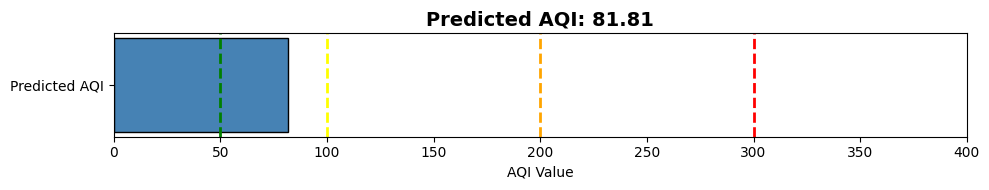

In [55]:
# Visual prediction output
sample_pred = rf_pred[0]

fig, ax = plt.subplots(figsize=(10, 2))
ax.barh(['Predicted AQI'], [sample_pred], color='steelblue', edgecolor='black')
ax.axvline(50, color='green', linestyle='--', linewidth=2)
ax.axvline(100, color='yellow', linestyle='--', linewidth=2)
ax.axvline(200, color='orange', linestyle='--', linewidth=2)
ax.axvline(300, color='red', linestyle='--', linewidth=2)
ax.set_xlim(0, 400)
ax.set_title(f'Predicted AQI: {sample_pred:.2f}', fontsize=14, fontweight='bold')
ax.set_xlabel('AQI Value')
plt.tight_layout()
plt.show()

In [56]:
# Interactive prediction (you can change these values)
print("🌍 CUSTOM AQI PREDICTION")
print("="*60)

# Change these values to test different scenarios
test_pm25 = 85.0
test_pm10 = 120.0
test_no2 = 45.0
test_co = 1.2
test_so2 = 15.0
test_o3 = 55.0

# Create input matching your feature set
# Note: You'll need to adjust city encoding based on your data
test_input = X_test.iloc[0].values.copy()  # Copy structure
test_input[0] = test_pm25
test_input[1] = test_pm10
test_input[2] = test_no2
test_input[3] = test_co
test_input[4] = test_so2
test_input[5] = test_o3

# Predict
test_scaled = scaler.transform([test_input])
predicted = rf_model.predict(test_scaled)[0]

print(f"PM2.5: {test_pm25}")
print(f"PM10:  {test_pm10}")
print(f"NO2:   {test_no2}")
print(f"CO:    {test_co}")
print(f"SO2:   {test_so2}")
print(f"O3:    {test_o3}")
print(f"\n🎯 Predicted AQI: {predicted:.2f}")

# AQI Category
if predicted <= 50:
    category = "Good 😊"
elif predicted <= 100:
    category = "Moderate 😐"
elif predicted <= 200:
    category = "Unhealthy ☹️"
elif predicted <= 300:
    category = "Very Unhealthy 😷"
else:
    category = "Hazardous ☠️"

print(f"Category: {category}")
print("="*60)

🌍 CUSTOM AQI PREDICTION
PM2.5: 85.0
PM10:  120.0
NO2:   45.0
CO:    1.2
SO2:   15.0
O3:    55.0

🎯 Predicted AQI: 171.75
Category: Unhealthy ☹️


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [57]:
'''# Download the model files (optional - for future use)
from google.colab import files

files.download('aqi_model.pkl')
files.download('scaler.pkl')

print("✅ Model files ready for download!")'''

'# Download the model files (optional - for future use)\nfrom google.colab import files\n\nfiles.download(\'aqi_model.pkl\')\nfiles.download(\'scaler.pkl\')\n\nprint("✅ Model files ready for download!")'

# **Project Complete**



---


📊 **Project Summary**

| Aspect | Details |
|--------|---------|
| **Dataset** | Air Quality Data (India) - 29,531+ records |
| **Features** | PM2.5, PM10, NO2, CO, SO2, O3, City, Date |
| **Target** | AQI (Air Quality Index) |
| **Models Tested** | 5 (Linear Regression, Decision Tree, Random Forest, SVR, KNN) |
| **Best Model** | Random Forest Regressor |
| **Accuracy** | R² Score: 0.929 (92.9%) |

---

🏆 **Key Achievements**

✅ Successfully predicted Air Quality Index with **92.9% accuracy**  
✅ Identified **PM10 and PM2.5** as most important features  
✅ Compared **5 different ML algorithms**  
✅ Created **reusable prediction model**  
✅ Generated comprehensive **visualizations and insights**

---

💡 **Key Insights**

- **PM10** has the highest correlation (0.81) with AQI
- **PM2.5** is the second most important factor (0.79)
- **Random Forest** outperformed all other models
- Model can help predict pollution levels for public health warnings

---


📚 **Technologies Used**

- **Python** - Programming Language
- **Pandas** - Data Manipulation
- **NumPy** - Numerical Computing
- **Matplotlib & Seaborn** - Data Visualization
- **Scikit-learn** - Machine Learning

---

👨‍💻 **Developed By**

- Kirandeep - 72520642
- Vishal - 72410698
- Shravan - 72411478


Btech CSE (AI and DS)



---

 *"Predicting Air Quality to Build a Healthier Future"* 🌍

---

---

**🎉 Thank You!**

---
